### "Шапка" с названием проекта

В этой ячейке вы найдете оглавление и ключевые этапы работы, которые помогут вам ориентироваться в процессе выполнения проекта. Проект разделен на пять основных этапов, четыре из которых (этапы 2, 3, 4 и 5) вам предлагается выполнить в этом Jupyter Notebook:

- Подготовка среды MLflow - Первый шаг, подготовка и запуск сервисов MLflow, был выполнен вне ноутбука и оформлен в виде shell скрипта. Это основа для работы с экспериментами и логирования результатов ваших моделей.

- Этап 2 - Исследовательский Анализ Данных (EDA): На этом этапе вы проведете тщательный анализ данных, чтобы лучше понять их структуру и особенности.

- Этап 3 - Генерация Признаков и Обучение Модели: После анализа данных вы сгенерируете новые признаки и обучите модель, используя эти признаки.

- Этап 4 - Отбор Признаков и Обучение Модели: На этом шаге вы отберете наиболее значимые признаки и снова обучите модель для улучшения ее качества.

- Этап 5 - Подбор Гиперпараметров и Обучение Финальной Версии Модели: Финальный этап проекта посвящен оптимизации гиперпараметров для достижения максимального качества модели.

Для удобства навигации и организации работы, пожалуйста, следуйте оглавлению и рекомендациям, описанным в каждом этапе.

> ### Важно: Переобучение моделей
> На каждом этапе проекта, где требуется переобучение модели, важно не просто выполнить эту процедуру, но и тщательно проверить качество модели на соответствующих выборках. Это включает в себя анализ метрик качества, визуализацию результатов, сравнение с предыдущими моделями и, при необходимости, корректировку.

> ### Важно: Разделение выборок
> Перед началом выполнения вашего проекта важно правильно подготовить данные, разделив их на подвыборки. Это позволит оценить производительность модели более объективно и управлять риском переобучения. В зависимости от ваших целей и доступных данных, вы можете использовать различные стратегии разделения:

1. Разделение на train/val/test: Это классический подход, где данные делятся на три части. Обучающая выборка (train) используется для первичного обучения моделей, валидационная (val) - для настройки гиперпараметров и выбора лучшей модели, а тестовая (test) - для финальной оценки производительности модели. Такой подход идеален, если у вас достаточно данных, чтобы разделить их и каждая из выборок была репрезентативна.

2. Разделение на train/test с кросс-валидацией на train: Если данных недостаточно для трех подвыборок, можно ограничиться разделением на обучающую и тестовую выборки. В этом случае кросс-валидация на обучающей выборке поможет оценить стабильность модели и подобрать гиперпараметры.

Определение способа разделения данных: Выбор метода разбиения данных на подвыборки — train, validation и test — должен быть обоснован особенностями вашего набора данных и задачами проекта. Возможные методы разделения, включая различные стратегии и правила, подробно описаны в [документации scikit-learn по разбиению данных](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html#sphx-glr-auto-examples-model-selection-plot-cv-indices-py). Вы можете следовать этим примерам или разработать собственный метод, исходя из специфики ваших данных.

Ваша задача - выбрать подходящий метод разделения данных исходя из объема и специфики ваших данных. Помните, что финальные метрики качества модели мы будем оценивать на тестовой выборке. Промежуточные результаты после каждого этапа проекта (например, после настройки гиперпараметров) следует оценивать на валидационной выборке, если таковая имеется. Это поможет вам корректно настроить модель перед финальной оценкой её производительности.

In [1]:
# сделайте разделение изначального набора данных в этой ячейке

#### Этап 2: Исследовательский Анализ Данных (EDA)
На этом этапе ваша задача - провести тщательный исследовательский анализ данных (EDA), чтобы глубже понять особенности и связи в предоставленном наборе данных. В процессе EDA вы должны обратить внимание на три ключевых аспекта, о которых мы говорили в теме 3 курса. Очень важно, чтобы все результаты вашего исследования, включая визуализации, статистический анализ и предварительные выводы, были аккуратно залогированы в MLflow.

Для более организованного исследования предлагаем следующие рекомендуемые шаги:
- Понимание данных: Первоначально ознакомьтесь с данными, изучите типы данных, проверьте наличие пропущенных значений.
- Визуализация данных: Используйте графики и диаграммы для визуализации распределений признаков и возможных взаимосвязей между ними.
- Статистический анализ: Примените статистические методы для изучения центральных тенденций, разброса и корреляций между признаками.
- Предварительные выводы: На основе проведённого анализа сформулируйте предварительные выводы о данных, которые помогут в дальнейшем этапе моделирования.

Помните, что EDA - это итеративный процесс, в котором вы можете возвращаться к предыдущим шагам для дополнительного анализа, если это будет необходимо. Все находки и выводы должны быть чётко зафиксированы и легко доступны для команды проекта.


In [2]:
# 2.1 Загрузка данных

In [3]:
%pip install --upgrade pyOpenSSL cryptography
%pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import subprocess
import sys
import tempfile
import time
from pathlib import Path

from autofeat import AutoFeatRegressor
from catboost import CatBoostRegressor
from dotenv import load_dotenv
import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.catboost
import mlflow.sklearn
from mlflow.models.signature import infer_signature
from mlflow.tracking import MlflowClient
from mlxtend.feature_selection import SequentialFeatureSelector
import nbformat
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.stats import loguniform, randint
import seaborn as sns
from sqlalchemy import create_engine, text

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    KFold,
    RandomizedSearchCV,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    KBinsDiscretizer,
    OneHotEncoder,
    PolynomialFeatures,
    StandardScaler,
)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

import optuna
from optuna.integration.mlflow import MLflowCallback

/home/mle-user/.local/lib/python3.10/site-packages/pydantic/_internal/_fields.py:151: UserWarning: Field "model_server_url" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/home/mle-user/.local/lib/python3.10/site-packages/pydantic/_internal/_config.py:322: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
  warnings.warn(message, UserWarning)


In [ ]:
load_dotenv()

source_engine = create_engine(
    f"postgresql+psycopg2://"
    f"{os.getenv('DB_SOURCE_USER')}:"
    f"{os.getenv('DB_SOURCE_PASSWORD')}@"
    f"{os.getenv('DB_SOURCE_HOST')}:"
    f"{os.getenv('DB_SOURCE_PORT')}/"
    f"{os.getenv('DB_SOURCE_NAME')}?sslmode=require"
)

destination_engine = create_engine(
    f"postgresql+psycopg2://"
    f"{os.getenv('DB_DESTINATION_USER')}:"
    f"{os.getenv('DB_DESTINATION_PASSWORD')}@"
    f"{os.getenv('DB_DESTINATION_HOST')}:"
    f"{os.getenv('DB_DESTINATION_PORT')}/"
    f"{os.getenv('DB_DESTINATION_NAME')}?sslmode=require"
)

with source_engine.connect() as connection:
    result = connection.execute(text("""
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema = 'public'
        AND table_type = 'BASE TABLE'
        ORDER BY table_name;
    """))
    
    print("SOURCE TABLES:")
    for row in result:
        print(row[0])

SOURCE TABLES:
alembic_version
alt_users_churn
buildings
buildings_and_flats
buildings_and_flats_clean
clean_users_churn
datasets
experiment_tags
experiments
flats
input_tags
inputs
latest_metrics
metrics
model_version_tags
model_versions
params
registered_model_aliases
registered_model_tags
registered_models
runs
tags
users_churn


In [6]:
data = pd.read_sql(
    "SELECT * FROM buildings_and_flats_clean",
    source_engine
)

print(data.shape)
display(data.head())

(140199, 18)


,id,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator,building_id,floor,kitchen_area,living_area,rooms,is_apartment,studio,total_area,price
0,0,1965,6,55.717113,37.781120,2.64,84,12,True,6220,9,9.9,19.900000,1,False,False,35.099998,9500000
1,1,2001,2,55.794849,37.608013,3.00,97,10,True,18012,7,0.0,16.600000,1,False,False,43.000000,13500000
2,2,2000,4,55.740040,37.761742,2.70,80,10,True,17821,9,9.0,32.000000,2,False,False,56.000000,13500000
3,3,2002,4,55.672016,37.570877,2.64,771,17,True,18579,1,10.1,43.099998,3,False,False,76.000000,20000000
4,4,1971,1,55.808807,37.707306,2.60,208,9,True,9293,3,3.0,14.000000,1,False,False,24.000000,5200000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140199 entries, 0 to 140198
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 140199 non-null  int64  
 1   build_year         140199 non-null  int64  
 2   building_type_int  140199 non-null  int64  
 3   latitude           140199 non-null  float64
 4   longitude          140199 non-null  float64
 5   ceiling_height     140199 non-null  float64
 6   flats_count        140199 non-null  int64  
 7   floors_total       140199 non-null  int64  
 8   has_elevator       140199 non-null  bool   
 9   building_id        140199 non-null  int64  
 10  floor              140199 non-null  int64  
 11  kitchen_area       140199 non-null  float64
 12  living_area        140199 non-null  float64
 13  rooms              140199 non-null  int64  
 14  is_apartment       140199 non-null  bool   
 15  studio             140199 non-null  bool   
 16  to

In [8]:
# 2.3 Анализ признаков для модели

In [9]:
# 1. Пропуски
missing = pd.DataFrame({
    "Пропуски": data.isna().sum(),
    "Доля пропусков, %": (
        data.isna().mean() * 100
    ).round(2)
})

display(missing.sort_values("Пропуски", ascending=False))

print("Всего пропущенных значений:",
      data.isna().sum().sum())

print("Строк с хотя бы одним пропуском:",
      data.isna().any(axis=1).sum())

# 2. Дубликаты
duplicates = data.duplicated().sum()

print("\nКоличество полных дубликатов:", duplicates)

print("Доля дубликатов, %:",
      round(duplicates / len(data) * 100, 2))

,Пропуски,"Доля пропусков, %"
id,0,0.0
build_year,0,0.0
building_type_int,0,0.0
latitude,0,0.0
longitude,0,0.0
ceiling_height,0,0.0
flats_count,0,0.0
floors_total,0,0.0
has_elevator,0,0.0
building_id,0,0.0


Всего пропущенных значений: 0
Строк с хотя бы одним пропуском: 0

Количество полных дубликатов: 0
Доля дубликатов, %: 0.0


In [11]:
# 2.2. Общий обзор датасета

In [12]:
exclude_cols = [
    "id",
    "building_id",
    "building_type_int",
    "has_elevator",
    "is_apartment",
    "studio",
    "latitude",
    "longitude"
]

stats = data.drop(columns=exclude_cols, errors="ignore").describe().T

stats.loc["price", stats.columns != "count"] /= 1_000_000
stats = stats.rename(index={"price": "price (млн руб.)"})

stats = stats.rename(columns={
    "count": "Количество",
    "mean": "Среднее",
    "std": "Ст. отклонение",
    "min": "Минимум",
    "25%": "25%",
    "50%": "Медиана",
    "75%": "75%",
    "max": "Максимум"
})

display(
    stats.style
    .format({
        "Количество": "{:,.0f}",
        **{
            col: "{:,.2f}"
            for col in stats.columns
            if col != "Количество"
        }
    }, thousands=" ", decimal=",")
    .background_gradient(cmap="Blues", subset=["Среднее"])
)

,Количество,Среднее,Ст. отклонение,Минимум,25%,Медиана,75%,Максимум
build_year,140 199,"1 986,54","22,07","1 901,00","1 969,00","1 985,00","2 007,00","2 023,00"
ceiling_height,140 199,"2,75","0,20","2,00","2,64","2,64","2,80","5,00"
flats_count,140 199,"253,00","207,04","1,00","112,00","201,00","324,00","1 630,00"
floors_total,140 199,"14,13","6,89","1,00","9,00","14,00","17,00","60,00"
floor,140 199,"7,48","5,72","1,00","3,00","6,00","10,00","56,00"
kitchen_area,140 199,"9,00","5,14","0,00","6,18","8,80","10,20","100,00"
living_area,140 199,"30,89","22,94","0,00","19,00","29,43","41,20","433,00"
rooms,140 199,"2,12","0,98","1,00","1,00","2,00","3,00","17,00"
total_area,140 199,"61,39","37,13","11,00","39,20","52,90","71,40","960,30"
price (млн руб.),140 199,"17,17","21,26","1,49","8,90","11,80","16,80","905,84"


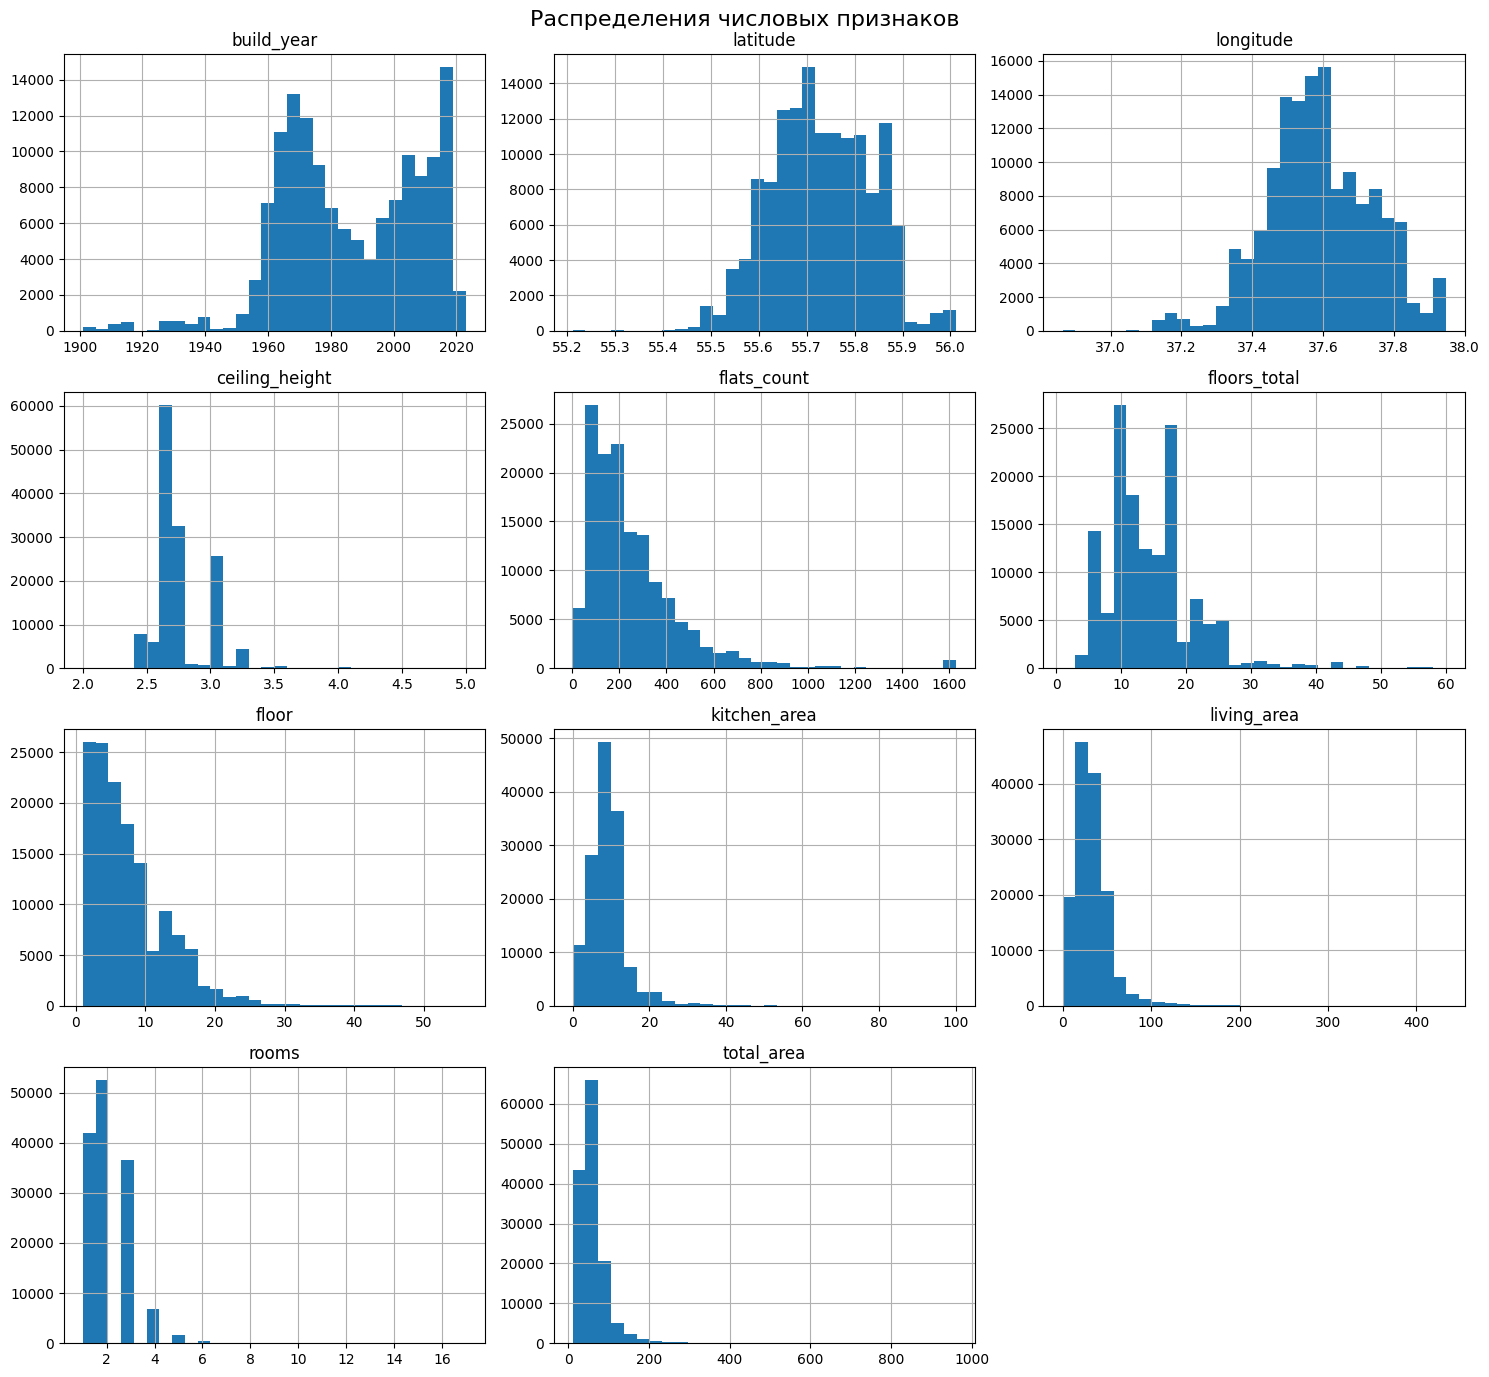

In [13]:
numeric_features = [
    "build_year",
    "latitude",
    "longitude",
    "ceiling_height",
    "flats_count",
    "floors_total",
    "floor",
    "kitchen_area",
    "living_area",
    "rooms",
    "total_area"
]

data[numeric_features].hist(
    bins=30,
    figsize=(15, 14),
    layout=(4, 3)
)

plt.suptitle("Распределения числовых признаков", fontsize=16)
plt.tight_layout()
plt.show()

- Была проведена загрузка данных которые были обработаны в прошлом спринте. Удалены выбросы, пропуски и дубликаты. Датасет полностью готов к этапу обучения. Список изменений и логику в принятии решений можно посмотреть в файле под названием <b>MLE_project1.ipynb</b>.
- Проведена визуализация числовых признаков.

In [14]:
# 2.4 Анализ целевой переменной

In [15]:
print(data['price'].describe().apply(lambda x: f'{x:,.0f}'))

count        140,199
mean      17,170,764
std       21,260,162
min        1,490,000
25%        8,900,000
50%       11,800,000
75%       16,800,000
max      905,841,024
Name: price, dtype: object


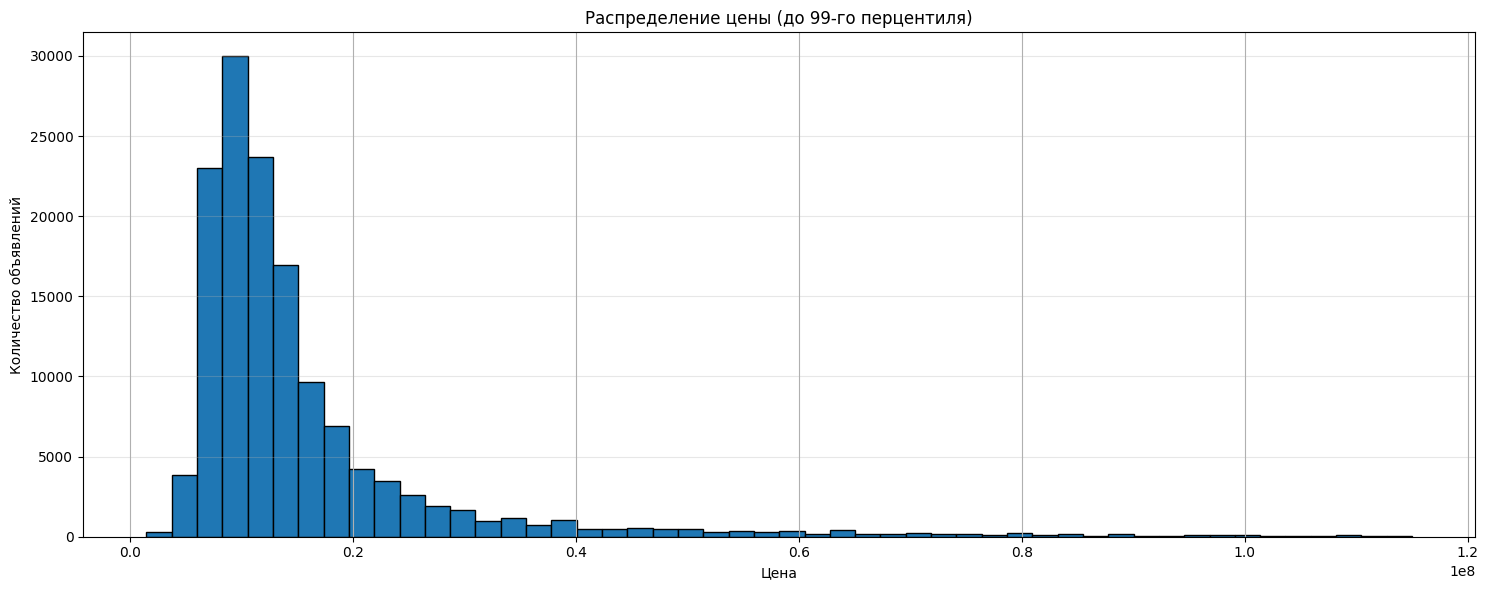

In [16]:
price_99 = data['price'].quantile(0.99)

data[data['price'] <= price_99]['price'].hist(
    figsize=(15, 6),
    bins=50,
    edgecolor='black'
)

plt.xlabel('Цена')
plt.ylabel('Количество объявлений')
plt.title('Распределение цены (до 99-го перцентиля)')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
data.sort_values('price', ascending=False)[
    ['price', 'total_area', 'rooms', 'build_year']
].head(10)

,price,total_area,rooms,build_year
29698,905841024,920.000000,10,2008
112765,602000000,752.000000,10,2005
53641,602000000,764.100000,10,2005
65124,561375744,800.000000,5,1997
56657,495000000,508.899994,7,2006
133580,495000000,528.500000,8,2006
52283,485992000,525.000000,7,2001
53624,485992000,525.000000,7,2001
77413,482734720,493.000000,6,2012
112714,475162336,525.000000,7,2001


In [18]:
# 2.4 Анализ целевой переменной в зависимости от различных признаков

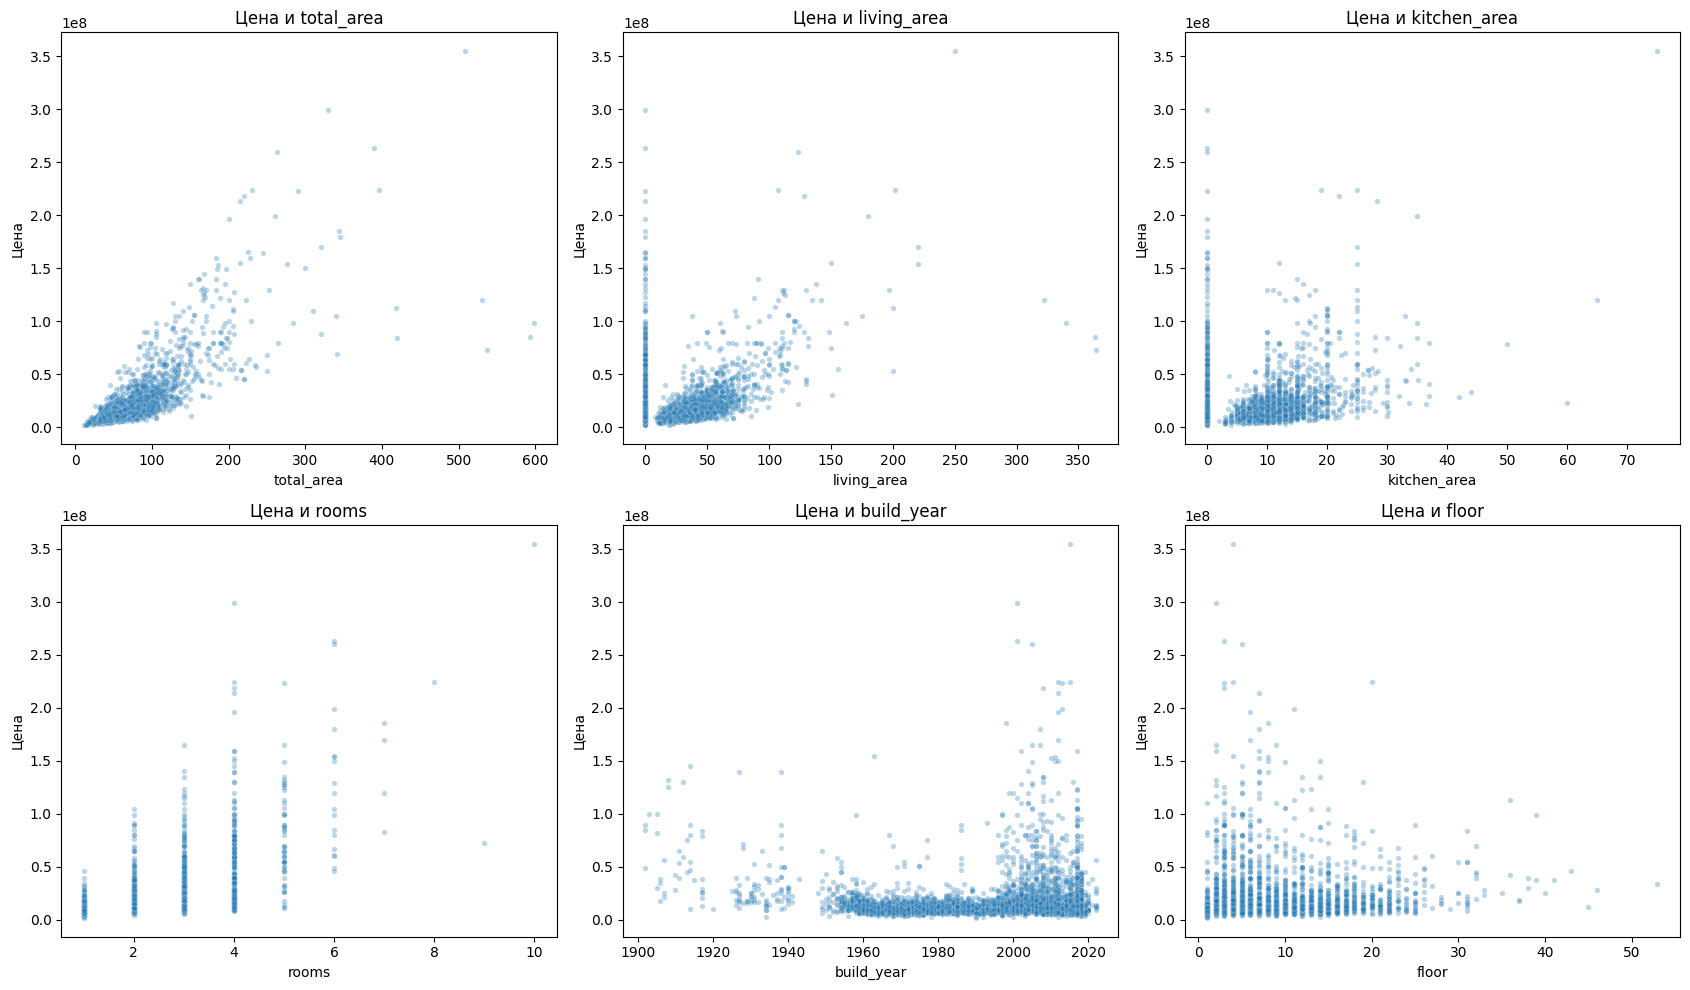

In [19]:
features = [
    "total_area",
    "living_area",
    "kitchen_area",
    "rooms",
    "build_year",
    "floor"
]

sample = data.sample(
    n=min(5000, len(data)),
    random_state=42
)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for ax, feature in zip(axes.flat, features):
    sns.scatterplot(
        data=sample,
        x=feature,
        y="price",
        alpha=0.3,
        s=15,
        ax=ax
    )
    ax.set_title(f"Цена и {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Цена")

plt.tight_layout()
plt.show()

In [20]:
area_features = ["living_area", "kitchen_area"]

for feature in area_features:

    # Создаём индикатор отсутствующего значения
    data[f"{feature}_missing"] = (
        data[feature].isna() | (data[feature] == 0)
    ).astype(int)

    # Выводим количество нулевых значений
    print(f"\nПризнак: {feature}")
    print(f"Нулевых значений: {(data[feature] == 0).sum()}")

    # Заменяем нули на NaN
    data[feature] = data[feature].replace(0, np.nan)

    print(f"Пропусков после обработки: {data[feature].isna().sum()}")

print(f"\nРазмер датасета: {data.shape}")


Признак: living_area
Нулевых значений: 18043
Пропусков после обработки: 18043

Признак: kitchen_area
Нулевых значений: 11171
Пропусков после обработки: 11171

Размер датасета: (140199, 20)


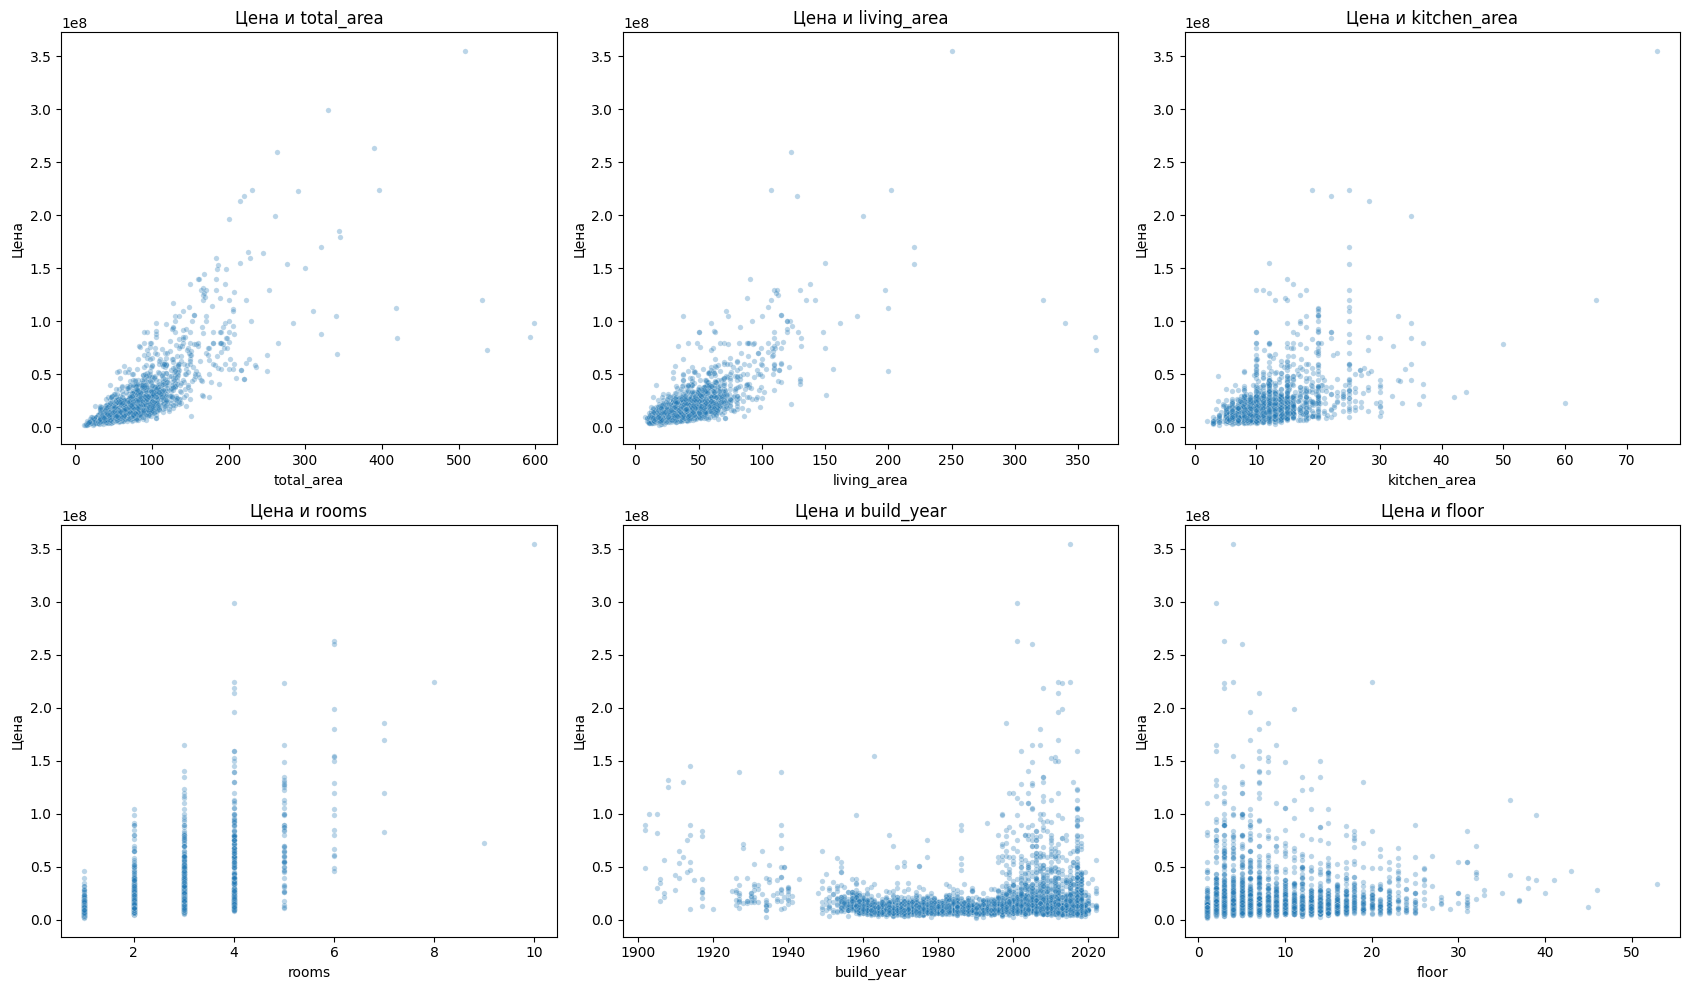

In [21]:
features = [
    "total_area",
    "living_area",
    "kitchen_area",
    "rooms",
    "build_year",
    "floor"
]

sample = data.sample(
    n=min(5000, len(data)),
    random_state=42
)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for ax, feature in zip(axes.flat, features):
    sns.scatterplot(
        data=sample,
        x=feature,
        y="price",
        alpha=0.3,
        s=15,
        ax=ax
    )
    ax.set_title(f"Цена и {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Цена")

plt.tight_layout()
plt.show()

Решено заполнить пропуски в колонках kitchen_area и living_area значением NaN.

2026-09-26 19:52:57,917 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-09-26 19:52:58,059 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-26 19:52:58,266 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-26 19:52:58,330 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


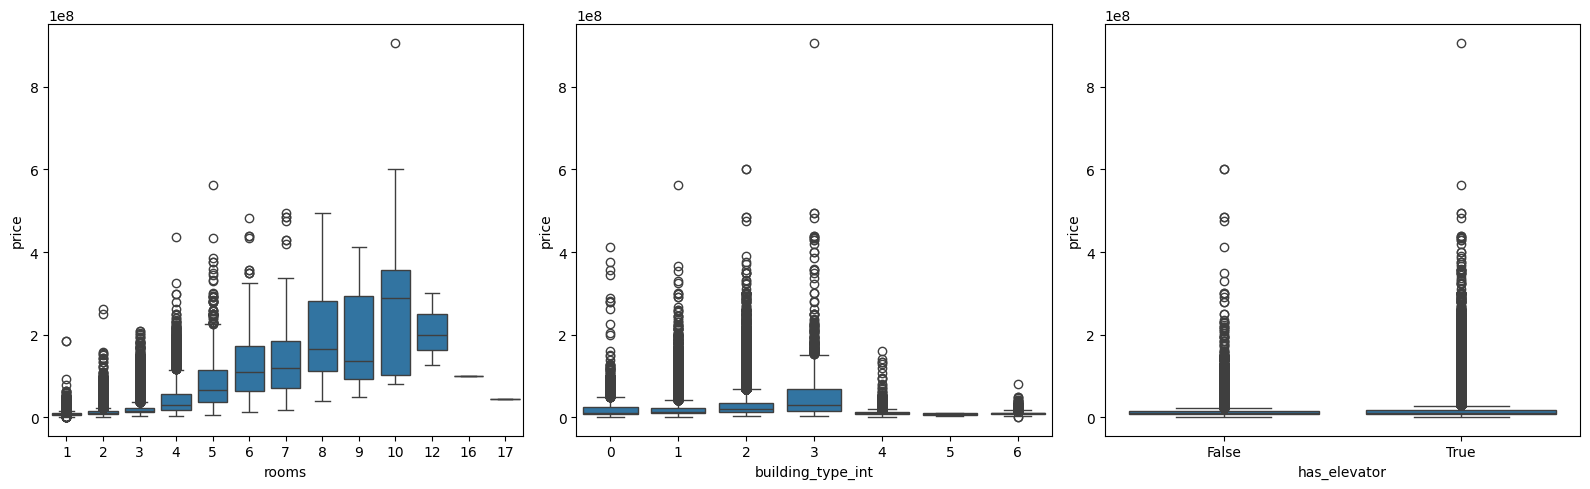

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(
    data=data,
    x="rooms",
    y="price",
    ax=axes[0]
)

sns.boxplot(
    data=data,
    x="building_type_int",
    y="price",
    ax=axes[1]
)

sns.boxplot(
    data=data,
    x="has_elevator",
    y="price",
    ax=axes[2]
)

plt.tight_layout()
plt.show()

Чем больше комнат тем меньше выбросов, видимо вариативность объявлений снижается с увеличение кол-ва комнат. 

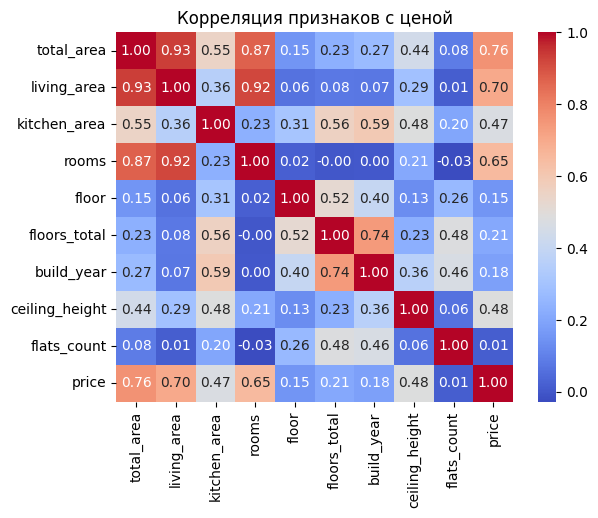

In [23]:
numeric_features = [
    "total_area",
    "living_area",
    "kitchen_area",
    "rooms",
    "floor",
    "floors_total",
    "build_year",
    "ceiling_height",
    "flats_count"
]

corr =data[numeric_features + ["price"]].corr(
    method="spearman"
)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Корреляция признаков с ценой")
plt.show()

Первичный корреляционный анализ показал какие признаки будут полезны для МО.
- общая площадь
- жилая площадь
- количества комнат
- площадь кухни
- высота потолков

In [24]:
# 2.5 Выводы после EDA

<b>Вывод по исследовательскому анализу</b>
- Сильная линейная зависимость для total_area: График price и total_area» показывает наиболее выраженную прямую зависимость. С ростом общей площади цена стабильно растет. Основной массив данных сосредоточен в диапазоне до 200 кв.м.

- Аномалии (выбросы): На графиках площадей (особенно living_area и kitchen_area) видны объекты с нулевой или близкой к нулю площадью, но при этом имеющие высокую цену. Это явные ошибки в данных (пропуски или некорректный ввод), которые требуют предобработки перед дальнейшим анализом.

- Дискретный характер rooms: Количество комнат — это категориальный/дискретный признак. Цена растет при переходе от 1 к 4 комнатам. Однако для объектов с 5 и более комнатными квартирами плотность данных падает, и появляются единичные дорогие элитные объекты.

- Влияние этажа (floor): Основной спрос и предложение сосредоточены на этажах от 1 до 15. С ростом этажности (выше 20-30 этажа) количество предложений резко снижается, но средняя цена высотных объектов остается стабильно высокой (вероятно, это видовые пентхаусы или квартиры в современных небоскребах). Объекты на первом этаже традиционно могут стоить дешевле, образуя плотное облако у нижней границы оси Y.

- Временной провал: На графике отчетливо виден провал в данных в районе 1940–1950 годов (что исторически объясняется спадом гражданского строительства во время и сразу после Великой Отечественной войны).

- Экспоненциальный рост в новостройках: Основной кластер дорогих объектов и высокая плотность точек сосредоточены в периоде после 2000 года. Современное жилье ценится значительно выше. При этом старый фонд (1960–1990 гг., эпоха панельного домостроения) имеет стабильно низкую и однородную ценовую категорию.

In [25]:
# 2.6 логирование артефактов в MLflow

In [61]:
TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

EXPERIMENT_NAME = "eda_real_estate"
RUN_NAME = "eda"

NOTEBOOK_PATH = Path(
    "/home/mle-user/mle-project-sprint-2-v001/"
    "mle-project-sprint-2-v001/model_improvement/"
    "project_template_sprint_2.ipynb"
)

MARKDOWN_PATH = NOTEBOOK_PATH.parent / "eda_conclusions.md"

print("Notebook:", NOTEBOOK_PATH)
print("Файл существует:", NOTEBOOK_PATH.is_file())

mlflow.set_tracking_uri(
    f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}"
)

if not NOTEBOOK_PATH.is_file():
    raise FileNotFoundError(
        f"Ноутбук не найден: {NOTEBOOK_PATH}"
    )

notebook = nbformat.read(
    NOTEBOOK_PATH,
    as_version=4
)

# Находим последнюю Markdown-ячейку,
# которая начинается с заголовка "Выводы"

conclusions = None

for cell in notebook.cells:
    if cell.cell_type != "markdown":
        continue

    content = cell.source.strip()

    if "<b>Вывод по исследовательскому анализу</b>" in content:
        conclusions = content
        break

if conclusions is None:
    raise ValueError("Ячейка с выводами EDA не найдена.")

MARKDOWN_PATH.write_text(
    conclusions,
    encoding="utf-8"
)

print("Выводы сохранены:", MARKDOWN_PATH)
print(conclusions)


# Создаём или выбираем эксперимент
mlflow.set_experiment(EXPERIMENT_NAME)

# Логируем артефакты
with mlflow.start_run(run_name=RUN_NAME) as run:

    run_id = run.info.run_id

    mlflow.set_tag("stage", "EDA")
    mlflow.set_tag("dataset", "real_estate")

    mlflow.log_artifact(
        str(NOTEBOOK_PATH),
        artifact_path="notebook"
    )

    mlflow.log_artifact(
        str(MARKDOWN_PATH),
        artifact_path="conclusions"
    )

# Проверяем результаты после завершения run
client = MlflowClient()

expected_artifacts = {
    "notebook": NOTEBOOK_PATH.name,
    "conclusions": MARKDOWN_PATH.name
}

for folder, filename in expected_artifacts.items():

    artifacts = client.list_artifacts(
        run_id,
        path=folder
    )

    paths = [artifact.path for artifact in artifacts]

    print(f"\n{folder}:")
    for path in paths:
        print(" -", path)

    expected_path = f"{folder}/{filename}"

    if expected_path not in paths:
        raise RuntimeError(
            f"Артефакт {expected_path} не найден"
        )

# Проверяем статус эксперимента
run_info = client.get_run(run_id)

print("\nExperiment:", EXPERIMENT_NAME)
print("Run ID:", run_id)
print("Status:", run_info.info.status)

Notebook: /home/mle-user/mle-project-sprint-2-v001/mle-project-sprint-2-v001/model_improvement/project_template_sprint_2.ipynb
Файл существует: True
Выводы сохранены: /home/mle-user/mle-project-sprint-2-v001/mle-project-sprint-2-v001/model_improvement/eda_conclusions.md
<b>Вывод по исследовательскому анализу</b>
- Сильная линейная зависимость для total_area: График price и total_area» показывает наиболее выраженную прямую зависимость. С ростом общей площади цена стабильно растет. Основной массив данных сосредоточен в диапазоне до 200 кв.м.

- Аномалии (выбросы): На графиках площадей (особенно living_area и kitchen_area) видны объекты с нулевой или близкой к нулю площадью, но при этом имеющие высокую цену. Это явные ошибки в данных (пропуски или некорректный ввод), которые требуют предобработки перед дальнейшим анализом.

- Дискретный характер rooms: Количество комнат — это категориальный/дискретный признак. Цена растет при переходе от 1 к 4 комнатам. Однако для объектов с 5 и более ком

#### Этап 3: Генерация Признаков и Обучение Новой Версии Модели
После тщательного исследовательского анализа данных (EDA), вы, скорее всего, сформировали несколько гипотез относительно новых признаков, которые могут улучшить качество вашей модели. На этом этапе, мы предлагаем вам приступить к генерации новых признаков и последующему обучению модели, используя два подхода:

Ручная генерация признаков: Используйте ваше понимание данных и результаты EDA для создания новых признаков.
Автоматическая генерация признаков: Воспользуйтесь библиотеками для автоматической генерации признаков, чтобы облегчить и ускорить этот процесс.
Важно: Для признаков, созданных вручную, рекомендуется использовать объекты sklearn, такие как Pipeline и ColumnTransformer. Это позволит автоматизировать процесс преобразования данных и облегчить поддержку вашего проекта.

После генерации новых признаков, наступает время обучить новую версию вашей модели, используя эти признаки. Не забудьте залогировать все результаты, включая новые признаки, параметры модели и метрики качества, в MLflow для удобства отслеживания изменений и результатов.

Рекомендуемые шаги:

- Определение и генерация новых признаков на основе ваших гипотез.
- Использование библиотек для автоматической генерации признаков, если это применимо.
- Интеграция новых признаков в вашу модель с помощью Pipeline или ColumnTransformer для ручно созданных признаков.
- Обучение новой версии модели с использованием всех доступных признаков.
- Логирование результатов в MLflow для документирования и анализа эффективности новых признаков и модели.

Этот этап проекта критически важен для повышения точности и эффективности вашей модели. Тщательная работа на этом этапе может существенно повлиять на итоговое качество моделирования.


In [27]:
# 3.1 ручная генерация признаков

In [28]:
df = data.copy()

numeric_features = [
    "build_year",
    "latitude",
    "longitude",
    "ceiling_height",
    "flats_count",
    "floors_total",
    "floor",
    "total_area",
    "living_area",
    "kitchen_area",
    "rooms"
]

categorical_features = [
    "building_type_int",
    "has_elevator",
    "is_apartment",
    "studio"
]

poly_features = [
    "total_area",
    "living_area",
    "kitchen_area",
    "rooms"
]

bin_features = [
    "total_area",
    "build_year",
    "floor"
]

features = numeric_features + categorical_features

X = df[features]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (112159, 15)
Test: (28040, 15)


In [29]:
# 3.2 оборачивание всех преобразований в объекты sklearn

In [30]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

polynomial_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(
        degree=2,
        include_bias=False
    ))
])

bins_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("bins", KBinsDiscretizer(
        n_bins=5,
        encode="onehot-dense",
        strategy="quantile"
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("poly", polynomial_transformer, poly_features),
        ("bins", bins_transformer, bin_features)
    ],
    remainder="drop"
)

In [31]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostRegressor(
        iterations=1000,
        depth=6,
        learning_rate=0.05,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        verbose=100,
        thread_count=-1
    ))
])

start = time.perf_counter()

model_pipeline.fit(X_train, y_train)

train_time = time.perf_counter() - start

start = time.perf_counter()

y_pred = model_pipeline.predict(X_test)

predict_time = time.perf_counter() - start

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)


print("\nРезультаты CatBoostRegressor")

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.4f}")

print(f"Время обучения: {train_time:.2f} сек.")
print(f"Время предсказания: {predict_time:.2f} сек.")

0:	learn: 20555468.1601225	total: 80ms	remaining: 1m 19s
100:	learn: 7913686.9343100	total: 2.4s	remaining: 21.4s
200:	learn: 7071415.0085630	total: 4.79s	remaining: 19s
300:	learn: 6580335.5237547	total: 7.38s	remaining: 17.1s
400:	learn: 6275947.2314822	total: 10.5s	remaining: 15.7s
500:	learn: 6049001.9390979	total: 14.3s	remaining: 14.3s
600:	learn: 5866614.9862797	total: 16.5s	remaining: 10.9s
700:	learn: 5709030.8770645	total: 18.7s	remaining: 7.97s
800:	learn: 5580651.9508822	total: 20.8s	remaining: 5.17s
900:	learn: 5448118.7403553	total: 23s	remaining: 2.52s
999:	learn: 5328569.4944557	total: 25.1s	remaining: 0us

Результаты CatBoostRegressor
MAE: 3,128,102.65
RMSE: 6,354,861.73
R²: 0.9093
Время обучения: 30.15 сек.
Время предсказания: 0.44 сек.


In [32]:
fitted_preprocessor = model_pipeline.named_steps[
    "preprocessor"
]

# Названия всех признаков после преобразований
feature_names = fitted_preprocessor.get_feature_names_out()

print("Исходное количество признаков:", X_train.shape[1])
print("Количество признаков после преобразований:", len(feature_names))

# Показываем полиномиальные признаки
print("\nПолиномиальные признаки:")
for name in feature_names:
    if name.startswith("poly__"):
        print(name)

# Показываем дискретизированные признаки
print("\nДискретизированные признаки:")
for name in feature_names:
    if name.startswith("bins__"):
        print(name)

Исходное количество признаков: 15
Количество признаков после преобразований: 52

Полиномиальные признаки:
poly__total_area
poly__living_area
poly__kitchen_area
poly__rooms
poly__total_area^2
poly__total_area living_area
poly__total_area kitchen_area
poly__total_area rooms
poly__living_area^2
poly__living_area kitchen_area
poly__living_area rooms
poly__kitchen_area^2
poly__kitchen_area rooms
poly__rooms^2

Дискретизированные признаки:
bins__total_area_0.0
bins__total_area_1.0
bins__total_area_2.0
bins__total_area_3.0
bins__total_area_4.0
bins__build_year_0.0
bins__build_year_1.0
bins__build_year_2.0
bins__build_year_3.0
bins__build_year_4.0
bins__floor_0.0
bins__floor_1.0
bins__floor_2.0
bins__floor_3.0
bins__floor_4.0


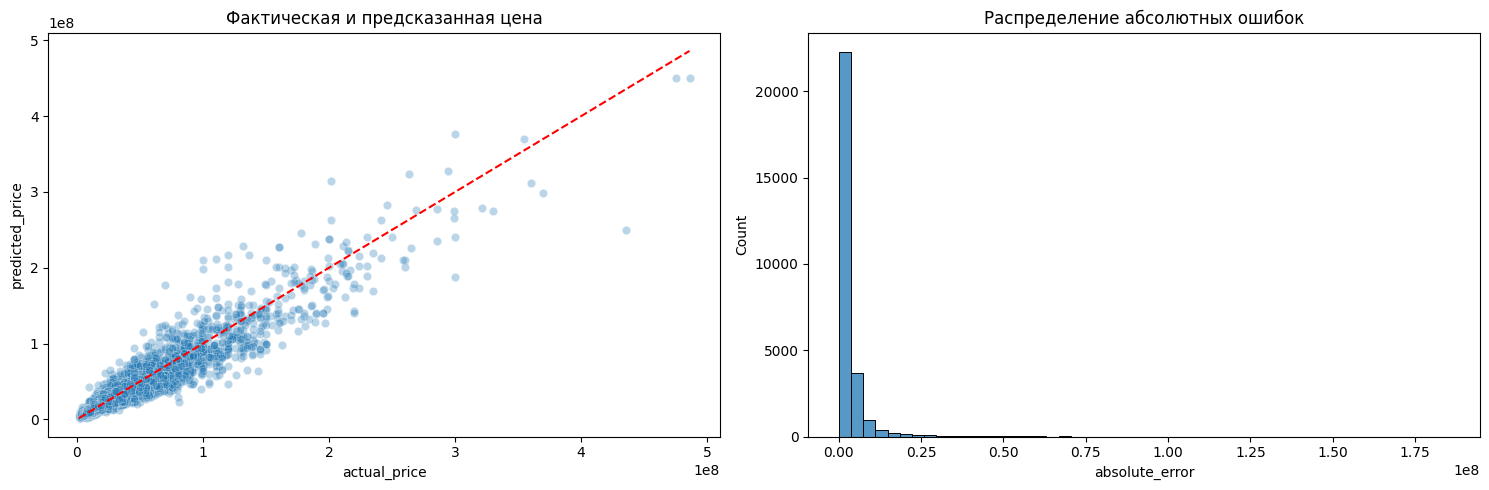

In [33]:
results = pd.DataFrame({
    "actual_price": y_test,
    "predicted_price": y_pred
})

results["absolute_error"] = abs(
    results["actual_price"] - results["predicted_price"]
)

results["relative_error"] = (
    results["absolute_error"] /
    results["actual_price"]
) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data=results,
    x="actual_price",
    y="predicted_price",
    alpha=0.3,
    ax=axes[0]
)

limits = [
    min(results["actual_price"].min(),
        results["predicted_price"].min()),
    max(results["actual_price"].max(),
        results["predicted_price"].max())
]

axes[0].plot(limits, limits, "r--")
axes[0].set_title("Фактическая и предсказанная цена")

sns.histplot(
    results["absolute_error"],
    bins=50,
    ax=axes[1]
)

axes[1].set_title("Распределение абсолютных ошибок")

plt.tight_layout()
plt.show()

In [34]:
# 3.3 автоматическая генерация признаков

In [35]:
autofeat_features = [
    "total_area",
    "living_area",
    "kitchen_area",
    "rooms",
    "floor",
    "floors_total",
    "build_year"
]

X_af_train = X_train[autofeat_features].copy()
X_af_test = X_test[autofeat_features].copy()


af_imputer = SimpleImputer(strategy="median")

X_af_train = pd.DataFrame(
    af_imputer.fit_transform(X_af_train),
    columns=autofeat_features,
    index=X_train.index
)

X_af_test = pd.DataFrame(
    af_imputer.transform(X_af_test),
    columns=autofeat_features,
    index=X_test.index
)

autofeat_model = AutoFeatRegressor(
    feateng_steps=1,
    featsel_runs=1,
    transformations=(
        "1/",
        "log",
        "sqrt",
        "^2"
    ),
    n_jobs=-1,
    verbose=1
)

start = time.perf_counter()

X_af_train_new = autofeat_model.fit_transform(
    X_af_train,
    y_train
)

af_fit_time = time.perf_counter() - start

start = time.perf_counter()

X_af_test_new = autofeat_model.transform(
    X_af_test
)

af_transform_time = time.perf_counter() - start

print("Исходных признаков:", X_af_train.shape[1])
print("После AutoFeat:", X_af_train_new.shape[1])
print(f"Генерация признаков: {af_fit_time:.2f} сек.")
print(f"Преобразование теста: {af_transform_time:.2f} сек.")

2026-09-26 19:53:34,636 INFO: [AutoFeat] The 1 step feature engineering process could generate up to 28 features.
2026-09-26 19:53:34,637 INFO: [AutoFeat] With 112159 data points this new feature matrix would use about 0.01 gb of space.
2026-09-26 19:53:34,641 INFO: [feateng] Step 1: transformation of original features


2026-09-26 19:53:38,559 INFO: [feateng] Generated 27 transformed features from 7 original features - done.
2026-09-26 19:53:38,583 INFO: [feateng] Generated altogether 28 new features in 1 steps
2026-09-26 19:53:38,584 INFO: [feateng] Removing correlated features, as well as additions at the highest level
2026-09-26 19:53:38,645 INFO: [feateng] Generated a total of 17 additional features
2026-09-26 19:53:38,777 INFO: [featsel] Feature selection run 1/1


[featsel] Scaling data...done.


2026-09-26 19:53:44,373 INFO: [featsel] 17 features after 1 feature selection runs
/home/mle-user/.local/lib/python3.10/site-packages/autofeat/featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:
2026-09-26 19:53:44,560 INFO: [featsel] 16 features after correlation filtering
2026-09-26 19:53:45,523 INFO: [featsel] 12 features after noise filtering
2026-09-26 19:53:45,526 INFO: [AutoFeat] Computing 6 new features.


2026-09-26 19:53:46,592 INFO: [AutoFeat]     6/    6 new features ...done.
2026-09-26 19:53:46,597 INFO: [AutoFeat] Final dataframe with 13 feature columns (6 new).
2026-09-26 19:53:46,598 INFO: [AutoFeat] Training final regression model.


2026-09-26 19:53:46,858 INFO: [AutoFeat] Trained model: largest coefficients:
2026-09-26 19:53:46,859 INFO: 81535650.69226822
2026-09-26 19:53:46,860 INFO: 634228859.568241 * 1/total_area
2026-09-26 19:53:46,862 INFO: 5679359.567098 * 1/kitchen_area
2026-09-26 19:53:46,863 INFO: -4595375.110188 * 1/rooms
2026-09-26 19:53:46,863 INFO: -4396079.082671 * rooms
2026-09-26 19:53:46,864 INFO: -2826153.699646 * 1/floor
2026-09-26 19:53:46,865 INFO: 811296.871275 * total_area
2026-09-26 19:53:46,866 INFO: -204532.893247 * living_area
2026-09-26 19:53:46,866 INFO: -125186.684865 * floor
2026-09-26 19:53:46,867 INFO: -79285.856159 * floors_total
2026-09-26 19:53:46,868 INFO: -52441.830683 * build_year
2026-09-26 19:53:46,870 INFO: -311.279604 * total_area**2
2026-09-26 19:53:46,871 INFO: 297.033551 * living_area**2
2026-09-26 19:53:46,891 INFO: [AutoFeat] Final score: 0.7358
2026-09-26 19:53:46,894 INFO: [AutoFeat] Computing 6 new features.
2026-09-26 19:53:46,905 INFO: [AutoFeat]     6/    6 ne

Исходных признаков: 76 new features
После AutoFeat: 13
Генерация признаков: 12.26 сек.
Преобразование теста: 0.02 сек.


In [36]:
fitted_preprocessor = model_pipeline.named_steps["preprocessor"]

X_train_prepared = fitted_preprocessor.transform(X_train)
X_test_prepared = fitted_preprocessor.transform(X_test)

new_af_features = [
    col for col in X_af_train_new.columns
    if col not in autofeat_features
]

print("Новых признаков AutoFeat:", len(new_af_features))
print(new_af_features)

X_train_enriched = sparse.hstack([
    sparse.csr_matrix(X_train_prepared),
    sparse.csr_matrix(
        X_af_train_new[new_af_features].to_numpy()
    )
], format="csr")

X_test_enriched = sparse.hstack([
    sparse.csr_matrix(X_test_prepared),
    sparse.csr_matrix(
        X_af_test_new[new_af_features].to_numpy()
    )
], format="csr")

print("Train:", X_train_enriched.shape)
print("Test:", X_test_enriched.shape)

Новых признаков AutoFeat: 6
['1/rooms', '1/floor', '1/total_area', 'total_area**2', 'living_area**2', '1/kitchen_area']
Train: (112159, 58)
Test: (28040, 58)


In [37]:
# 3.4 обучение новой версии модели

In [38]:
model = CatBoostRegressor(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    loss_function="RMSE",
    random_seed=42,
    verbose=100,
    thread_count=-1
)

# Обучение
start = time.perf_counter()

model.fit(
    X_train_enriched,
    y_train
)

train_time = time.perf_counter() - start

# Предсказание
start = time.perf_counter()

y_pred = model.predict(X_test_enriched)

predict_time = time.perf_counter() - start

# Оценка
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.4f}")
print(f"Время обучения: {train_time:.2f} сек.")
print(f"Время предсказания: {predict_time:.2f} сек.")

0:	learn: 20550872.0808148	total: 20.7ms	remaining: 20.7s
100:	learn: 7786480.1434390	total: 3.08s	remaining: 27.5s
200:	learn: 7000930.7106050	total: 5.97s	remaining: 23.7s
300:	learn: 6513987.7623439	total: 8.65s	remaining: 20.1s
400:	learn: 6240973.8726678	total: 12.8s	remaining: 19.1s
500:	learn: 6021378.2117097	total: 17.6s	remaining: 17.6s
600:	learn: 5836824.5964826	total: 21.3s	remaining: 14.1s
700:	learn: 5683324.4795643	total: 25.6s	remaining: 10.9s
800:	learn: 5557801.3833274	total: 30.4s	remaining: 7.56s
900:	learn: 5432456.5766458	total: 34.1s	remaining: 3.74s
999:	learn: 5314499.9431009	total: 36.7s	remaining: 0us
MAE: 3,129,091.83
RMSE: 6,386,115.37
R²: 0.9084
Время обучения: 37.65 сек.
Время предсказания: 0.07 сек.


In [39]:
# 3.5 логирование артефактов в MLflow

In [40]:
TRACKING_URI = "http://127.0.0.1:5000"

EXPERIMENT_NAME = "real_estate_feature_engineering"
RUN_NAME = "catboost_sklearn_features"
REGISTRY_MODEL_NAME = "real_estate_price_model"

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_registry_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

NOTEBOOK_PATH = (
    "//model_improvement/project_template_sprint_2.ipynb"
)

input_example = X_train.head(5).copy()

example_predictions = model_pipeline.predict(
    input_example
)

signature = infer_signature(
    input_example,
    example_predictions
)

with mlflow.start_run(run_name=RUN_NAME) as run:

    run_id = run.info.run_id

    # Гиперпараметры модели
    mlflow.log_params({
        "model_type": "CatBoostRegressor",
        "iterations": 1000,
        "depth": 6,
        "learning_rate": 0.05,
        "random_seed": 42,
        "test_size": 0.2,
        "polynomial_degree": 2,
        "kbins_n_bins": 5,
        "feature_count": len(
            model_pipeline.named_steps[
                "preprocessor"
            ].get_feature_names_out()
        )
    })

    # Метрики и производительность
    mlflow.log_metrics({
        "test_mae": float(mae),
        "test_rmse": float(rmse),
        "test_r2": float(r2),
        "train_time_seconds": float(train_time),
        "predict_time_seconds": float(predict_time)
    })

    # Исходный код генерации признаков:
    # сохраняем ноутбук, если он существует
    if os.path.isfile(NOTEBOOK_PATH):
        mlflow.log_artifact(
            NOTEBOOK_PATH,
            artifact_path="source_code"
        )
    else:
        print(
            "Внимание: ноутбук не найден. "
            "Укажи правильный NOTEBOOK_PATH."
        )

    # Сохраняем список преобразованных признаков
    feature_names = (
        model_pipeline.named_steps["preprocessor"]
        .get_feature_names_out()
    )

    with tempfile.TemporaryDirectory() as tmpdir:

        features_path = os.path.join(
            tmpdir,
            "feature_names.txt"
        )

        with open(
            features_path,
            "w",
            encoding="utf-8"
        ) as f:
            f.write("\n".join(feature_names))

        mlflow.log_artifact(
            features_path,
            artifact_path="feature_engineering"
        )

        # Полный список установленных библиотек
        environment_path = os.path.join(
            tmpdir,
            "requirements.txt"
        )

        with open(
            environment_path,
            "w",
            encoding="utf-8"
        ) as f:
            subprocess.run(
                [
                    sys.executable,
                    "-m",
                    "pip",
                    "freeze"
                ],
                stdout=f,
                check=True
            )

        mlflow.log_artifact(
            environment_path,
            artifact_path="environment"
        )


    mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        artifact_path="model",
        signature=signature,
        input_example=input_example,
        registered_model_name=REGISTRY_MODEL_NAME
    )

    print("Experiment:", EXPERIMENT_NAME)
    print("Run ID:", run_id)
    print("Registered model:", REGISTRY_MODEL_NAME)

print("Логирование завершено.")

/home/mle-user/.local/lib/python3.10/site-packages/mlflow/models/signature.py:212: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  inputs = _infer_schema(model_input) if model_input is not None else None


Внимание: ноутбук не найден. Укажи правильный NOTEBOOK_PATH.


Registered model 'real_estate_price_model' already exists. Creating a new version of this model...
2026/09/26 19:54:34 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: real_estate_price_model, version 11


Experiment: real_estate_feature_engineering
Run ID: e1beb1833ead4bfb8aad7d5f9d9cbd32
Registered model: real_estate_price_model
Логирование завершено.


Created version '11' of model 'real_estate_price_model'.


In [ ]:
client = MlflowClient()

# Находим версию, созданную нашим экспериментом
versions = client.search_model_versions(
    f"name='{REGISTRY_MODEL_NAME}'"
)

matching_versions = [
    version
    for version in versions
    if version.run_id == run_id
]

if not matching_versions:
    raise RuntimeError(
        "Версия модели не найдена в Model Registry"
    )

model_version = max(
    matching_versions,
    key=lambda v: int(v.version)
)

print("Название:", model_version.name)
print("Версия:", model_version.version)
print("Run ID:", model_version.run_id)
print("Статус:", model_version.status)

# Загружаем зарегистрированную модель
model_uri = (
    f"models:/{REGISTRY_MODEL_NAME}/"
    f"{model_version.version}"
)

loaded_model = mlflow.pyfunc.load_model(model_uri)

# Проверяем предсказание на исходных данных
predictions = loaded_model.predict(
    X_test.head(5)
)

print("Предсказания:")
print(predictions)

Название: real_estate_price_model
Версия: 11
Run ID: e1beb1833ead4bfb8aad7d5f9d9cbd32
Статус: READY


Предсказания:
[11060561.22217564  8935302.2386924   9672125.15580921  8786344.71498984
  7793522.90456196]


#### Этап 4: Отбор Признаков и Обучение Новой Версии Модели
Создание новых признаков — это лишь часть работы. Следующий важный шаг — это убедиться в том, что каждый из этих признаков действительно вносит положительный вклад в качество модели. Некоторые признаки могут оказывать отрицательное влияние на модель, поэтому их следует исключить из анализа.

На этом этапе, мы рекомендуем вам применить различные методы отбора признаков для того, чтобы определить и удалить те признаки, которые не улучшают качество вашей модели. Цель этого этапа — максимизировать производительность модели, удалив избыточные или неинформативные признаки.

После тщательного отбора признаков, пора обучить новую версию вашей модели, уже без негативно влияющих на неё признаков. Важно залогировать результаты этого этапа, включая измененный набор признаков, параметры модели и полученные метрики качества, в MLflow для последующего анализа и сравнения.

Рекомендуемые шаги:

- Применение методов отбора признаков для идентификации и исключения признаков, ухудшающих качество модели.
- Анализ влияния каждого признака на модель, чтобы понять, какие из них наиболее ценные.
- Обучение новой версии модели без негативно влияющих признаков.
- Логирование всех изменений и результатов в MLflow, включая конечный набор признаков, параметры модели и метрики качества.

Этот этап не только поможет улучшить качество вашей модели, но и даст глубокое понимание о важности и влиянии отдельных признаков на результаты моделирования.


In [42]:
# 4.1 Отбор признаков при помощи метода номер 1

In [43]:
# Полные названия 58 признаков
all_feature_names = (
    list(fitted_preprocessor.get_feature_names_out())
    + new_af_features
)

assert len(all_feature_names) == X_train_enriched.shape[1]

# Предварительная модель для оценки важности
prefilter_model = CatBoostRegressor(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
    thread_count=-1
)

prefilter_model.fit(X_train_enriched, y_train)

importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": prefilter_model.feature_importances_
}).sort_values("importance", ascending=False)

# Сохраняем индексы 15 наиболее важных признаков
top_features = importance.head(15)["feature"].tolist()

top_indices = [
    all_feature_names.index(name)
    for name in top_features
]

# Отбираем признаки
X_train_top = X_train_enriched[:, top_indices]
X_test_top = X_test_enriched[:, top_indices]

print("Признаков до отбора:", X_train_enriched.shape[1])
print("Признаков после предварительного отбора:", X_train_top.shape[1])

display(importance.head(15))

Признаков до отбора: 58
Признаков после предварительного отбора: 15


,feature,importance
55,total_area**2,15.597027
23,poly__total_area,13.456163
2,num__longitude,12.418460
1,num__latitude,10.759584
3,num__ceiling_height,8.686324
54,1/total_area,8.492281
27,poly__total_area^2,6.830194
7,num__total_area,5.885549
0,num__build_year,3.447228
4,num__flats_count,2.186900


In [44]:
# 4.3 Анализ отобранных признаков при помощи двух методов и формирование финального списка с признаками для модели

In [45]:
# Подвыборка для ускорения отбора
indices, _ = train_test_split(
    np.arange(X_train_top.shape[0]),
    train_size=12000,
    random_state=42
)

# mlxtend удобнее использовать с плотной матрицей
X_selection = X_train_top[indices].toarray()
y_selection = y_train.iloc[indices]

selector_model = CatBoostRegressor(
    iterations=150,
    depth=5,
    learning_rate=0.05,
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
    thread_count=4
)

cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Forward Selection
sfs = SequentialFeatureSelector(
    selector_model,
    k_features=10,
    forward=True,
    floating=False,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=2
)

start = time.perf_counter()
sfs.fit(X_selection, y_selection)
sfs_time = time.perf_counter() - start

# Backward Selection
sbs = SequentialFeatureSelector(
    selector_model,
    k_features=10,
    forward=False,
    floating=False,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=2
)

start = time.perf_counter()
sbs.fit(X_selection, y_selection)
sbs_time = time.perf_counter() - start

print("SFS RMSE:", -sfs.k_score_)
print("SBS RMSE:", -sbs.k_score_)

print("SFS time:", sfs_time)
print("SBS time:", sbs_time)

TBB Warning: The number of workers is currently limited to 1. The request for 3 workers is ignored. Further requests for more workers will be silently ignored until the limit changes.

TBB Warning: The number of workers is currently limited to 1. The request for 3 workers is ignored. Further requests for more workers will be silently ignored until the limit changes.

TBB Warning: The number of workers is currently limited to 1. The request for 3 workers is ignored. Further requests for more workers will be silently ignored until the limit changes.



SFS RMSE: 10177801.308389606
SBS RMSE: 10194988.914750142
SFS time: 143.208501681
SBS time: 124.14649636799999


In [46]:
# 4.4 Обучение новой версии модели

In [47]:
results = []
trained_models = {}

# Данные после предварительного отбора
X_train_dense = X_train_top.toarray()
X_test_dense = X_test_top.toarray()

for name, selector in [
    ("SFS", sfs),
    ("SBS", sbs)
]:
    selected_indices = list(selector.k_feature_idx_)

    X_tr = X_train_dense[:, selected_indices]
    X_te = X_test_dense[:, selected_indices]

    model = CatBoostRegressor(
        iterations=1000,
        depth=6,
        learning_rate=0.05,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
        thread_count=-1
    )

    start = time.perf_counter()
    model.fit(X_tr, y_train)
    train_time = time.perf_counter() - start

    start = time.perf_counter()
    predictions = model.predict(X_te)
    predict_time = time.perf_counter() - start

    metrics = {
        "method": name,
        "mae": mean_absolute_error(y_test, predictions),
        "rmse": np.sqrt(mean_squared_error(y_test, predictions)),
        "r2": r2_score(y_test, predictions),
        "train_time": train_time,
        "predict_time": predict_time,
        "selection_time": sfs_time if name == "SFS" else sbs_time
    }

    results.append(metrics)

    trained_models[name] = {
        "model": model,
        "selector": selector,
        "selected_indices": selected_indices,
        "selected_features": [
            top_features[i] for i in selected_indices
        ],
        "metrics": metrics
    }

results_df = pd.DataFrame(results)

display(
    results_df.style.format({
        "mae": "{:,.0f}",
        "rmse": "{:,.0f}",
        "r2": "{:.4f}",
        "train_time": "{:.2f}",
        "predict_time": "{:.3f}",
        "selection_time": "{:.2f}"
    })
)


,method,mae,rmse,r2,train_time,predict_time,selection_time
0,SFS,"3,232,852","6,887,681",0.8934,15.75,0.049,143.21
1,SBS,"3,166,190","6,642,072",0.9009,19.24,0.027,124.15


In [ ]:
class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, indices):
        self.indices = indices

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        result = X[:, self.indices]
        if hasattr(result, "toarray"):
            result = result.toarray()
        return result

In [49]:
# 4.5 Логирование всех артефактов в MLflow

In [50]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_registry_uri("http://127.0.0.1:5000")
mlflow.set_experiment("real_estate_feature_selection")

REGISTRY_MODEL_NAME = "real_estate_price_model"

def make_json_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, np.integer):
        return int(obj)

    if isinstance(obj, np.floating):
        return float(obj)

    if isinstance(obj, dict):
        return {
            str(k): make_json_serializable(v)
            for k, v in obj.items()
        }

    if isinstance(obj, (list, tuple)):
        return [
            make_json_serializable(v)
            for v in obj
        ]

    return obj

for name, item in trained_models.items():

    selector = item["selector"]
    model = item["model"]
    metrics = item["metrics"]

    # Составляем пайплайн из уже обученных объектов
    final_pipeline = Pipeline([
        ("prefilter", ColumnSelector(top_indices)),
        ("selector", selector),
        ("model", model)
    ])

    # Входная матрица содержит 58 признаков
    input_example = X_train_enriched[:5].toarray()
    output_example = final_pipeline.predict(input_example)

    signature = infer_signature(
        input_example,
        output_example
    )

    with mlflow.start_run(
        run_name=f"real_estate_{name.lower()}"
    ) as run:

        mlflow.log_params({
            "selection_method": name,
            "initial_features": 58,
            "prefilter_features": 15,
            "selected_features": 10,
            "selection_cv": 3,
            "selection_sample_size": 12000,
            "iterations": 1000,
            "depth": 6,
            "learning_rate": 0.05
        })

        mlflow.log_metrics({
            k: float(v)
            for k, v in metrics.items()
            if k != "method"
        })

        # История последовательного отбора
        selection_history = make_json_serializable(
            selector.get_metric_dict()
        )

        mlflow.log_dict(
            selection_history,
            f"selection/{name.lower()}_history.json"
        )

        mlflow.log_dict(
            {"selected_features": item["selected_features"]},
            "selection/selected_features.json"
        )

        # График важности выбранных признаков
        feature_importance = pd.Series(
            model.feature_importances_,
            index=item["selected_features"]
        ).sort_values()

        fig, ax = plt.subplots(figsize=(10, 6))
        feature_importance.plot.barh(ax=ax)
        ax.set_title(f"{name}: важность признаков")
        ax.set_xlabel("Feature importance")
        plt.tight_layout()

        mlflow.log_figure(
            fig,
            f"plots/{name.lower()}_importance.png"
        )
        plt.close(fig)

        # Окружение
        with tempfile.TemporaryDirectory() as tmpdir:
            env_path = os.path.join(
                tmpdir, "requirements.txt"
            )

            with open(env_path, "w") as f:
                subprocess.run(
                    [sys.executable, "-m", "pip", "freeze"],
                    stdout=f,
                    check=True
                )

            mlflow.log_artifact(
                env_path,
                artifact_path="environment"
            )

        # Код эксперимента
        notebook_path = (
            "model_improvement/project_template_sprint_2.ipynb"
        )

        if os.path.isfile(notebook_path):
            mlflow.log_artifact(
                notebook_path,
                artifact_path="source_code"
            )

        # Модель и новая версия в реестре
        mlflow.sklearn.log_model(
            sk_model=final_pipeline,
            artifact_path="model",
            signature=signature,
            input_example=input_example,
            registered_model_name=REGISTRY_MODEL_NAME
        )

        print(name, "Run ID:", run.info.run_id)


Registered model 'real_estate_price_model' already exists. Creating a new version of this model...
2026/09/26 19:59:52 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: real_estate_price_model, version 12
Created version '12' of model 'real_estate_price_model'.


SFS Run ID: 2acff8f1a0ab40888525021a637ed630


Registered model 'real_estate_price_model' already exists. Creating a new version of this model...
2026/09/26 19:59:55 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: real_estate_price_model, version 13


SBS Run ID: 23120398370a47de8bdb96a254ffff1b


Created version '13' of model 'real_estate_price_model'.


### Этап 5 - подбор гиперпараметров и обучение новой версии модели
После того как мы уделили значительное внимание качеству модели через создание и отбор признаков, пришло время для финального штриха — подбора гиперпараметров. Этот этап является ключевым в финальной части проекта второго спринта, где ваша задача — оптимизировать гиперпараметры модели для достижения наилучшего качества.

Рекомендуется подобрать гиперпараметры как минимум двумя различными методами (например, с использованием Grid Search и Random Search), чтобы вы могли сравнить результаты и выбрать наиболее эффективный набор гиперпараметров для вашей модели. После определения оптимальных гиперпараметров, наступает время обучить финальную версию модели, используя ваши новые признаки.

Рекомендуемые шаги:

- Выбор методов для подбора гиперпараметров: Определитесь с методами, которые вы будете использовать для подбора гиперпараметров (например, Grid Search, Random Search, Bayesian Optimization).
- Подбор гиперпараметров: Примените выбранные методы для нахождения оптимальных значений гиперпараметров вашей модели.
- Сравнение результатов: Анализируйте и сравнивайте результаты, полученные различными методами, для определения наилучшего набора гиперпараметров.
- Обучение финальной модели: Используя выбранные гиперпараметры, обучите финальную версию вашей модели на новых признаках.
- Документирование процесса и результатов: Залогируйте все шаги и результаты в MLflow, включая сравнение методов подбора гиперпараметров и характеристики финальной модели.

Этот этап позволит вам максимально улучшить качество вашей модели перед финальной оценкой, предоставив полное понимание важности и влияния гиперпараметров на производительность модели.

In [51]:
# 5.1 Подбор гиперпарметров при мощи метода номер 1

In [ ]:
# Выбор метода отбора по результатам CV
selection_method = max(
    trained_models,
    key=lambda name: trained_models[name]["selector"].k_score_
)

selected_indices = list(
    trained_models[selection_method]["selected_indices"]
)

# Индексы относительно исходных 58 признаков
final_indices = [
    top_indices[i]
    for i in selected_indices
]

X_train_selected = X_train_enriched[:, final_indices]
X_test_selected = X_test_enriched[:, final_indices]

selected_feature_names = (
    trained_models[selection_method]["selected_features"]
)

print("Метод отбора:", selection_method)
print("Признаков:", X_train_selected.shape[1])
print("Train:", X_train_selected.shape)
print("Test:", X_test_selected.shape)


Метод отбора: SFS
Признаков: 10
Train: (112159, 10)
Test: (28040, 10)


In [ ]:
TRACKING_URI = "http://127.0.0.1:5000"
EXPERIMENT_NAME = "real_estate_hyperparameter_tuning"
REGISTRY_MODEL_NAME = "real_estate_price_model"

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_registry_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

N_TRIALS = 10

cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

fixed_params = {
    "iterations": 500,
    "loss_function": "RMSE",
    "random_seed": 42,
    "verbose": False,
    "thread_count": 4
}

def evaluate_cv(params):
    model = CatBoostRegressor(
        **fixed_params,
        **params
    )

    scores = cross_val_score(
        model,
        X_train_selected,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=1
    )

    return -scores.mean()


2026/09/26 19:59:57 INFO mlflow.tracking.fluent: Experiment with name 'real_estate_hyperparameter_tuning' does not exist. Creating a new experiment.


In [ ]:
def objective(trial):
    params = {
        "depth": trial.suggest_int(
            "depth", 4, 8
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.15, log=True
        ),
        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg", 1.0, 10.0
        ),
        "random_strength": trial.suggest_float(
            "random_strength", 0.1, 5.0
        )
    }

    return evaluate_cv(params)


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name="real_estate_optuna",
    storage="sqlite:///real_estate_optuna.db",
    load_if_exists=True
)

mlflow_callback = MLflowCallback(
    tracking_uri=TRACKING_URI,
    metric_name="cv_rmse",
    create_experiment=False,
    mlflow_kwargs={
        "experiment_id": mlflow.get_experiment_by_name(
            EXPERIMENT_NAME
        ).experiment_id,
        "nested": True
    }
)

start = time.perf_counter()

with mlflow.start_run(
    run_name="optuna_tpe_search"
) as optuna_run:

    study.optimize(
        objective,
        n_trials=N_TRIALS,
        callbacks=[mlflow_callback]
    )

    optuna_time = time.perf_counter() - start

    optuna_best_params = study.best_params
    optuna_best_rmse = study.best_value

    mlflow.log_params({
        "method": "Optuna_TPE",
        "selection_method": selection_method,
        "n_trials": N_TRIALS,
        "cv_folds": 3,
        **{
            f"best_{k}": v
            for k, v in optuna_best_params.items()
        }
    })

    mlflow.log_metrics({
        "best_cv_rmse": optuna_best_rmse,
        "search_time_seconds": optuna_time
    })

    mlflow.log_dict(
        {
            "best_params": optuna_best_params,
            "best_cv_rmse": optuna_best_rmse
        },
        "optimization/best_result.json"
    )

print("Optuna RMSE:", optuna_best_rmse)
print("Параметры:", optuna_best_params)
print("Время:", optuna_time)


[I 2026-09-26 20:01:21,931] Using an existing study with name 'real_estate_optuna' instead of creating a new one.


/tmp/ipykernel_2588/2891554627.py:30: ExperimentalWarning: MLflowCallback is experimental (supported from v1.4.0). The interface can change in the future.
  mlflow_callback = MLflowCallback(
[I 2026-09-26 20:01:38,823] Trial 1 finished with value: 7637360.401487298 and parameters: {'depth': 5, 'learning_rate': 0.13125830316209655, 'l2_leaf_reg': 7.587945476302646, 'random_strength': 3.0334265725654794}. Best is trial 0 with value: 7637360.401487298.
[I 2026-09-26 20:01:56,034] Trial 2 finished with value: 9223123.963329611 and parameters: {'depth': 4, 'learning_rate': 0.015256811898068502, 'l2_leaf_reg': 1.5227525095137953, 'random_strength': 4.344263114297182}. Best is trial 0 with value: 7637360.401487298.
[I 2026-09-26 20:02:20,202] Trial 3 finished with value: 7494360.27348461 and parameters: {'depth': 7, 'learning_rate': 0.06803900745073706, 'l2_leaf_reg': 1.185260448662222, 'random_strength': 4.852558275593772}. Best is trial 3 with value: 7494360.27348461.
[I 2026-09-26 20:02:53

Optuna RMSE: 7426074.69295292
Параметры: {'depth': 7, 'learning_rate': 0.08508292988780213, 'l2_leaf_reg': 2.2094931360129513, 'random_strength': 4.171743607855069}
Время: 553.565525075


In [ ]:
# 5.2 Подбор гиперпарметров при мощи метода номер 2

In [57]:
param_distributions = {
    "depth": randint(4, 9),
    "learning_rate": loguniform(0.01, 0.15),
    "l2_leaf_reg": loguniform(1.0, 10.0),
    "random_strength": loguniform(0.1, 5.0)
}

random_search = RandomizedSearchCV(
    estimator=CatBoostRegressor(**fixed_params),
    param_distributions=param_distributions,
    n_iter=N_TRIALS,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=1,
    refit=True,
    return_train_score=True,
    verbose=1
)

start = time.perf_counter()

with mlflow.start_run(
    run_name="random_search"
) as random_run:

    random_search.fit(
        X_train_selected,
        y_train
    )

    random_time = time.perf_counter() - start

    random_best_params = random_search.best_params_
    random_best_rmse = -random_search.best_score_

    mlflow.log_params({
        "method": "RandomizedSearchCV",
        "selection_method": selection_method,
        "n_iter": N_TRIALS,
        "cv_folds": 3,
        **{
            f"best_{k}": v
            for k, v in random_best_params.items()
        }
    })

    mlflow.log_metrics({
        "best_cv_rmse": random_best_rmse,
        "search_time_seconds": random_time
    })

    # Все результаты поиска
    cv_results = pd.DataFrame(
        random_search.cv_results_
    )

    mlflow.log_table(
        cv_results,
        "optimization/random_search_results.json"
    )

print("Random Search RMSE:", random_best_rmse)
print("Параметры:", random_best_params)
print("Время:", random_time)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Random Search RMSE: 7421679.749359236
Параметры: {'depth': 6, 'l2_leaf_reg': 2.4124703879446576, 'learning_rate': 0.14334061069667645, 'random_strength': 0.6208921295733548}
Время: 477.6158840600001


In [ ]:
# 5.3 Формирование списка гиперпараметров для новой модели

In [58]:

comparison = pd.DataFrame([
    {
        "method": "Optuna TPE",
        "cv_rmse": optuna_best_rmse,
        "search_time": optuna_time,
        "best_params": optuna_best_params
    },
    {
        "method": "RandomizedSearchCV",
        "cv_rmse": random_best_rmse,
        "search_time": random_time,
        "best_params": random_best_params
    }
])

display(
    comparison[
        ["method", "cv_rmse", "search_time"]
    ].sort_values("cv_rmse")
)

best_result = comparison.loc[
    comparison["cv_rmse"].idxmin()
]

best_method = best_result["method"]
best_params = best_result["best_params"]

print("Выбранный метод:", best_method)
print("Лучшие параметры:", best_params)


,method,cv_rmse,search_time
1,RandomizedSearchCV,7.421680e+06,477.615884
0,Optuna TPE,7.426075e+06,553.565525


Выбранный метод: RandomizedSearchCV
Лучшие параметры: {'depth': 6, 'l2_leaf_reg': 2.4124703879446576, 'learning_rate': 0.14334061069667645, 'random_strength': 0.6208921295733548}


In [ ]:
# 5.4 Обуение финальной версии модели

In [62]:
# Выбираем только признаки, отобранные на этапе 4
final_selector = ColumnTransformer(
    transformers=[
        ("selected", "passthrough", final_indices)
    ],
    remainder="drop"
)

final_pipeline = Pipeline([
    ("feature_selection", final_selector),
    ("model", CatBoostRegressor(
        **fixed_params,
        **best_params
    ))
])

# Измеряем полное время обучения
start = time.perf_counter()
final_pipeline.fit(X_train_enriched, y_train)
final_train_time = time.perf_counter() - start

# Измеряем время предсказания
start = time.perf_counter()
final_predictions = final_pipeline.predict(
    X_test_enriched
)
final_predict_time = time.perf_counter() - start

final_metrics = {
    "test_mae": mean_absolute_error(
        y_test, final_predictions
    ),
    "test_rmse": np.sqrt(
        mean_squared_error(y_test, final_predictions)
    ),
    "test_r2": r2_score(
        y_test, final_predictions
    ),
    "train_time_seconds": final_train_time,
    "predict_time_seconds": final_predict_time
}

print("Финальная модель")
print("Метод оптимизации:", best_method)

for key, value in final_metrics.items():
    print(f"{key}: {value:,.4f}")

Финальная модель
Метод оптимизации: RandomizedSearchCV
test_mae: 3,164,278.5639
test_rmse: 6,707,068.8957
test_r2: 0.8989
train_time_seconds: 15.8223
predict_time_seconds: 0.2376


In [ ]:
# 5.5 Логирование артефактов в MLflow

In [60]:
with mlflow.start_run(
    run_name="final_optimized_catboost"
) as run:

    mlflow.set_tags({
        "optimization_method": best_method,
        "feature_selection_method": selection_method,
        "project_stage": "5"
    })

    mlflow.log_params({
        **best_params,
        **fixed_params,
        "selected_features_count": len(final_indices),
        "optimization_method": best_method
    })

    mlflow.log_metrics({
        **final_metrics,
        "best_cv_rmse": float(
            best_result["cv_rmse"]
        )
    })

    # Сохраняем сравнение методов
    mlflow.log_table(
        comparison.assign(
            best_params=comparison["best_params"].astype(str)
        ),
        "optimization/method_comparison.json"
    )

    # Список выбранных признаков
    mlflow.log_dict(
        {"selected_features": selected_feature_names},
        "features/selected_features.json"
    )

    # График важности
    importance = pd.Series(
        final_pipeline.named_steps["model"].feature_importances_,
        index=selected_feature_names
    ).sort_values()

    fig, ax = plt.subplots(figsize=(10, 6))
    importance.plot.barh(ax=ax)

    ax.set_title("Final CatBoost feature importance")
    ax.set_xlabel("Importance")

    plt.tight_layout()

    mlflow.log_figure(
        fig,
        "plots/final_feature_importance.png"
    )
    plt.close(fig)

    # Полное окружение
    with tempfile.TemporaryDirectory() as tmpdir:
        env_path = os.path.join(
            tmpdir, "requirements.txt"
        )

        with open(env_path, "w") as f:
            subprocess.run(
                [sys.executable, "-m", "pip", "freeze"],
                stdout=f,
                check=True
            )

        mlflow.log_artifact(
            env_path,
            artifact_path="environment"
        )

    # Код эксперимента
    notebook_path = (
        "model_improvement/project_template_sprint_2.ipynb"
    )

    if os.path.isfile(notebook_path):
        mlflow.log_artifact(
            notebook_path,
            artifact_path="source_code"
        )

    # Сигнатура: вход — 58 обогащённых признаков
    input_example = X_train_enriched[:5].toarray()

    signature = infer_signature(
        input_example,
        final_pipeline.predict(input_example)
    )

    mlflow.sklearn.log_model(
        sk_model=final_pipeline,
        artifact_path="model",
        signature=signature,
        input_example=input_example,
        registered_model_name=REGISTRY_MODEL_NAME
    )

    final_run_id = run.info.run_id

print("Final Run ID:", final_run_id)

Registered model 'real_estate_price_model' already exists. Creating a new version of this model...
2026/09/26 20:21:32 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: real_estate_price_model, version 14


Final Run ID: cbdbbf7b20a94b72b511e61f209f47a1


Created version '14' of model 'real_estate_price_model'.
